In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_excel("Online retail.xlsx")
df.head()

,"shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil"
0,"burgers,meatballs,eggs"
1,chutney
2,"turkey,avocado"
3,"mineral water,milk,energy bar,whole wheat rice..."
4,low fat yogurt


## Data Preprocessing:

In [3]:
df = df[df.columns[0]].str.split(',', expand=True)
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,burgers,meatballs,eggs,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
1,chutney,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
2,turkey,avocado,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
3,mineral water,milk,energy bar,whole wheat rice,green tea,None,None,None,None,None,None,None,None,None,None,None,None,None,None
4,low fat yogurt,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None


In [4]:
df.duplicated().sum()

np.int64(2325)

In [5]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [6]:
df.isna().sum()

0        0
1      110
2      867
3     1843
4     2647
5     3312
6     3807
7     4195
8     4522
9     4781
10    4920
11    5022
12    5089
13    5129
14    5151
15    5168
16    5172
17    5172
18    5173
dtype: int64

In [7]:
# Replace NaN values with empty strings
df = df.fillna('')

In [8]:
transactions = df.apply(lambda row: [item for item in row if item != ''],axis=1).tolist()
transactions[:5]

[['burgers', 'meatballs', 'eggs'],
 ['chutney'],
 ['turkey', 'avocado'],
 ['mineral water', 'milk', 'energy bar', 'whole wheat rice', 'green tea'],
 ['low fat yogurt']]

## Association Rule Mining:

In [9]:
#!pip install mlxtend

In [10]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

In [11]:
te = TransactionEncoder()

# Fit and transform the transactions
te_array = te.fit(transactions).transform(transactions)
# Convert to DataFrame
encoded_df = pd.DataFrame(te_array, columns=te.columns_)
print("Encoded Data Shape:", encoded_df.shape)
encoded_df.head()

Encoded Data Shape: (5175, 120)


,asparagus,almonds,antioxydant juice,asparagus,avocado,babies food,bacon,barbecue sauce,black tea,blueberries,...,turkey,vegetables mix,water spray,white wine,whole weat flour,whole wheat pasta,whole wheat rice,yams,yogurt cake,zucchini
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,True,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [12]:
frequent_itemsets = apriori(encoded_df, min_support=0.01, use_colnames=True)
frequent_itemsets.head()

,support,itemsets
0,0.029179,(almonds)
1,0.011014,(antioxydant juice)
2,0.045797,(avocado)
3,0.012560,(bacon)
4,0.015459,(barbecue sauce)


In [13]:
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)
print("Number of rules generated:", len(rules))
rules.head()

Number of rules generated: 10


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,"(chocolate, chicken)",(mineral water),0.021256,0.299710,0.011014,0.518182,1.728943,1.0,0.004644,1.453432,0.430768,0.035536,0.311973,0.277466
1,"(chocolate, olive oil)",(mineral water),0.023575,0.299710,0.011981,0.508197,1.695627,1.0,0.004915,1.423923,0.420153,0.038485,0.297715,0.274085
2,"(eggs, ground beef)",(mineral water),0.028792,0.299710,0.014493,0.503356,1.679475,1.0,0.005863,1.410043,0.416570,0.046154,0.290802,0.275856
3,"(ground beef, frozen vegetables)",(mineral water),0.024541,0.299710,0.013333,0.543307,1.812775,1.0,0.005978,1.533393,0.459640,0.042884,0.347852,0.293897
4,"(ground beef, frozen vegetables)",(spaghetti),0.024541,0.229565,0.012560,0.511811,2.229480,1.0,0.006927,1.578149,0.565339,0.052000,0.366346,0.283262


## Analysis and Interpretation:

In [14]:
def format_itemset(itemset):
    return ', '.join(sorted(list(itemset)))

In [15]:
rules['antecedents_formatted'] = rules['antecedents'].apply(format_itemset)
rules['consequents_formatted'] = rules['consequents'].apply(format_itemset)
rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,antecedents_formatted,consequents_formatted
0,"(chocolate, chicken)",(mineral water),0.021256,0.299710,0.011014,0.518182,1.728943,1.0,0.004644,1.453432,0.430768,0.035536,0.311973,0.277466,"chicken, chocolate",mineral water
1,"(chocolate, olive oil)",(mineral water),0.023575,0.299710,0.011981,0.508197,1.695627,1.0,0.004915,1.423923,0.420153,0.038485,0.297715,0.274085,"chocolate, olive oil",mineral water
2,"(eggs, ground beef)",(mineral water),0.028792,0.299710,0.014493,0.503356,1.679475,1.0,0.005863,1.410043,0.416570,0.046154,0.290802,0.275856,"eggs, ground beef",mineral water
3,"(ground beef, frozen vegetables)",(mineral water),0.024541,0.299710,0.013333,0.543307,1.812775,1.0,0.005978,1.533393,0.459640,0.042884,0.347852,0.293897,"frozen vegetables, ground beef",mineral water
4,"(ground beef, frozen vegetables)",(spaghetti),0.024541,0.229565,0.012560,0.511811,2.229480,1.0,0.006927,1.578149,0.565339,0.052000,0.366346,0.283262,"frozen vegetables, ground beef",spaghetti


In [16]:
rules = rules.sort_values(by='lift', ascending=False)
print("Top 10 Association Rules (Sorted by Lift):")
top_rules = rules[['antecedents_formatted','consequents_formatted','support','confidence','lift']].head(10)
top_rules

Top 10 Association Rules (Sorted by Lift):


,antecedents_formatted,consequents_formatted,support,confidence,lift
4,"frozen vegetables, ground beef",spaghetti,0.012560,0.511811,2.229480
8,"milk, soup",mineral water,0.012367,0.576577,1.923781
3,"frozen vegetables, ground beef",mineral water,0.013333,0.543307,1.812775
9,"soup, spaghetti",mineral water,0.010821,0.523364,1.746235
6,"ground beef, pancakes",mineral water,0.010821,0.518519,1.730067
0,"chicken, chocolate",mineral water,0.011014,0.518182,1.728943
7,"milk, olive oil",mineral water,0.012367,0.512000,1.708317
1,"chocolate, olive oil",mineral water,0.011981,0.508197,1.695627
5,"ground beef, milk",mineral water,0.016039,0.506098,1.688623
2,"eggs, ground beef",mineral water,0.014493,0.503356,1.679475


#### Key Observations from Top 10 Rules

1. The rule {frozen vegetables, ground beef} → {spaghetti} has the highest lift (2.23), indicating a very strong association. Customers purchasing frozen vegetables and ground beef are more than twice as likely to also purchase spaghetti compared to random chance. This suggests a clear meal-based purchasing pattern.

2. Mineral water appears as the consequent in 8 out of the top 10 rules, indicating it is a highly associated product and frequently purchased alongside other items.

3. The rule {milk, soup} → {mineral water} has high confidence (57.6%), meaning more than half of the customers buying milk and soup also purchase mineral water.

4. Most confidence values are above 50%, indicating reliable association patterns between product combinations.

5. Support values range between 1% and 1.6%, meaning these combinations occur in a meaningful portion of total transactions while still representing specific purchasing behaviors.

6. The results suggest strong cross-selling opportunities, particularly involving mineral water and meal-related products such as ground beef, spaghetti, and soup.

In [17]:
antecedents = rules['antecedents_formatted'].value_counts().head(5)
consequents = rules['consequents_formatted'].value_counts().head(5)

print("Top 5 Most Frequent Antecedents:")
print(antecedents)

print("\nTop 5 Most Frequent Consequents:")
print(consequents)

Top 5 Most Frequent Antecedents:
antecedents_formatted
frozen vegetables, ground beef    2
milk, soup                        1
soup, spaghetti                   1
ground beef, pancakes             1
chicken, chocolate                1
Name: count, dtype: int64

Top 5 Most Frequent Consequents:
consequents_formatted
mineral water    9
spaghetti        1
Name: count, dtype: int64


- Mineral water appears in 9 out of 10 top rules. This means customers often buy mineral water with many other products.
- The combination of frozen vegetables and ground beef appears more than once. This shows these two items are commonly bought together.
- The rule frozen vegetables and ground beef → spaghetti has the highest lift, which means customers buying these items are very likely to also buy spaghetti.
- Ground beef appears in many rules, so it is an important product in customer purchases.
- Overall, mineral water and ground beef seem to be key products and can be used for promotions or bundle offers.

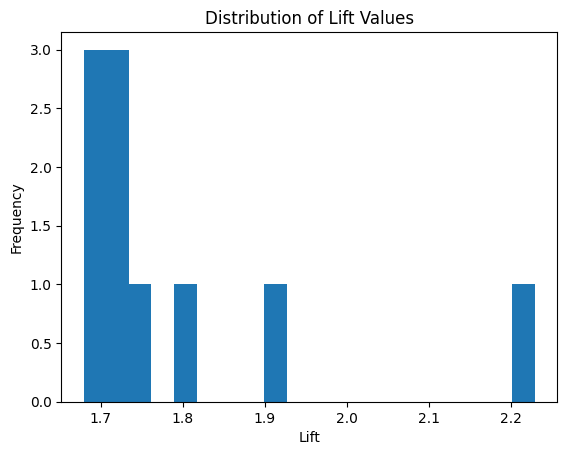

In [19]:
plt.hist(rules['lift'], bins=20)
plt.title('Distribution of Lift Values')
plt.xlabel('Lift')
plt.ylabel('Frequency')
plt.show()

- Lift values are mostly above 1.5, which shows strong positive associations between products.
- Some rules have lift above 2, indicating very strong relationships between certain item combinations.

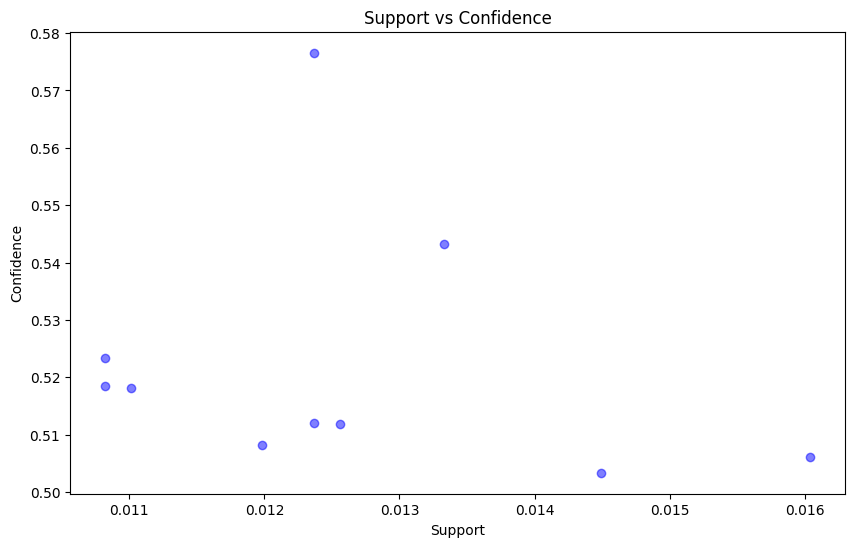

In [20]:
plt.figure(figsize=(10, 6))
plt.scatter(rules['support'], rules['confidence'], alpha=0.5, color='blue')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Support vs Confidence')
plt.show()

- Most rules have low support but moderate to high confidence, meaning they are reliable but not very frequent.
- There is no strong relationship between support and confidence, showing that highly confident rules are not always the most common ones.

In [21]:
high_lift_rules = rules[(rules['lift'] > 1.5) & (rules['support'] > 0.01)]
high_lift_rules[['antecedents_formatted', 'consequents_formatted', 'support', 'confidence', 'lift']]

,antecedents_formatted,consequents_formatted,support,confidence,lift
4,"frozen vegetables, ground beef",spaghetti,0.012560,0.511811,2.229480
8,"milk, soup",mineral water,0.012367,0.576577,1.923781
3,"frozen vegetables, ground beef",mineral water,0.013333,0.543307,1.812775
9,"soup, spaghetti",mineral water,0.010821,0.523364,1.746235
6,"ground beef, pancakes",mineral water,0.010821,0.518519,1.730067
0,"chicken, chocolate",mineral water,0.011014,0.518182,1.728943
7,"milk, olive oil",mineral water,0.012367,0.512000,1.708317
1,"chocolate, olive oil",mineral water,0.011981,0.508197,1.695627
5,"ground beef, milk",mineral water,0.016039,0.506098,1.688623
2,"eggs, ground beef",mineral water,0.014493,0.503356,1.679475


In [22]:
rules['antecedent_size'] = rules['antecedents'].apply(len)
rules['consequent_size'] = rules['consequents'].apply(len)

In [23]:
avg_antecedent_size = rules['antecedent_size'].mean()
avg_consequent_size = rules['consequent_size'].mean()

In [24]:
print("Average Antecedent Size:", avg_antecedent_size)
print("Average Consequent Size:", avg_consequent_size)

Average Antecedent Size: 2.0
Average Consequent Size: 1.0


- The average antecedent size is 2, and the average consequent size is 1.
- This means most rules involve two products leading to one related product, showing simple and clear purchasing patterns.

In [25]:
all_products = rules['antecedents'].apply(list) + rules['consequents'].apply(list)
product_counts = pd.Series([item for sublist in all_products for item in sublist]).value_counts()
product_counts

mineral water        9
ground beef          5
milk                 3
frozen vegetables    2
spaghetti            2
soup                 2
chocolate            2
olive oil            2
pancakes             1
chicken              1
eggs                 1
Name: count, dtype: int64

- Mineral water appears the most in the association rules, showing it is strongly connected with many products.
- Ground beef and milk also appear frequently, indicating they are important items in customer purchasing patterns.

### Observations

- Some rules have high lift values, which means those products have a strong relationship. For example, frozen vegetables and ground beef are often bought together with spaghetti, showing a clear meal-based pattern.
- Mineral water appears in many rules, especially as a consequent. This shows that customers frequently buy mineral water along with other products.
- Ground beef and milk also appear multiple times, which means they are important products in customer purchases.
- The average antecedent size is 2 and the average consequent size is 1. This shows that most rules involve two items leading to one related item, indicating simple and common buying behavior.

### Conclusion

Association rule mining helped identify strong product combinations. Mineral water and ground beef are key products. These insights can help in cross-selling and promotional strategies.

## Interview Questions:

#### 1. What is lift and why is it important in Association rules?

- Lift shows how strong the relationship is between two products. It tells us how much more likely the consequent product is purchased when the antecedent product is bought.

- If lift is greater than 1, it means there is a positive relationship. Higher lift means stronger association, which helps in finding meaningful product combinations.

#### 2.What is support and Confidence. How do you calculate them?

- Support shows how frequently a product combination appears in the dataset.
- It is calculated as:
Support = (Number of transactions containing the itemset) / (Total number of transactions)

- Confidence shows how often the consequent is purchased when the antecedent is purchased.
- It is calculated as:
Confidence = (Support of A and B together) / (Support of A)

- Support measures frequency, while confidence measures reliability of the rule.

#### 3.	What are some limitations or challenges of Association rules mining?

Some challenges are:

- It can generate too many rules.
- Choosing the right support and confidence values can be difficult.
- It may find rules that are not practically useful.
- It can become slow with very large datasets.